In [8]:
%load_ext autoreload
%autoreload 2
import os
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import geopandas as gpd
from pyproj import Transformer
from project.data_handling import * 
from shop.plotting.plotting_fxns import *
import pandas as pd

site_dict = {
    'wolverine':['N','B','EC'],
    'kahiltna':['K53','K17b'], 
    'kennicott':['GTL','GTH'], # ,'KC31'],
    'lemon_creek':['B','C','D'],
    'taku':['NWB1','TKG3'],
    'gulkana':['AU','B','D']
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Compare old shading masks (slow, individual point search) to new ones (GPU / vectorized)

FileNotFoundError: Could not find shadow file: /home/claire/Local/data/shading/01.09162_shadows.nc

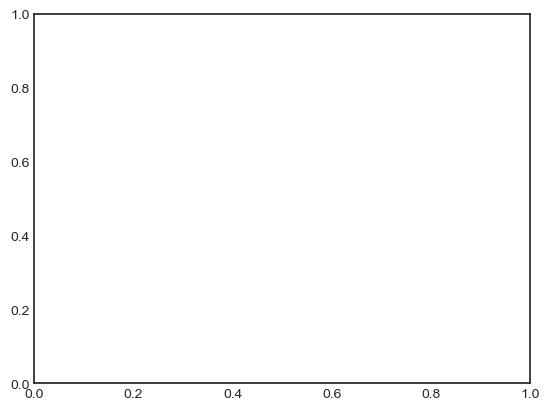

In [87]:
shading_fp = '/home/claire/Local/data/shading/'

# create figure
n_sites = np.sum([len(s) for _, s in site_dict.items()])
fig, ax = plt.subplots()
sites = []
i = 0
for glacier in site_dict:
    glacier_id = translate_rgi[glacier]['6']

    # load the shading file
    file_path = os.path.join(shading_fp, f"{glacier_id}_shadows.nc")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not find shadow file: {file_path}")

    ds = xr.open_dataset(file_path)

    # apply coordinate corrections as needed
    local_times = ds.time.values - np.timedelta64(8, "h")
    ds = ds.assign_coords(time=local_times)
    ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
    ds = ds.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])

    # read in the site constants file for this glacier
    df = pd.read_csv(f'data/by_glacier/{glacier}/site_constants.csv', index_col='site')

    for site in site_dict[glacier]:
        # grab lat/lon for this site and convert it to x/y
        point_to_grab = (df.loc[site, 'lat'], df.loc[site, 'lon'])
        transformer = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
        x_pts, y_pts = transformer.transform(point_to_grab[1], point_to_grab[0])

        # get xr DataArrays for the slicing variables
        target_x = xr.DataArray([x_pts], dims='points')
        target_y = xr.DataArray([y_pts], dims='points')

        new_ds = ds.sel(y=target_y, x=target_x, method='nearest').shadow_mask

        # load the old shadow mask
        old_mask = pd.read_csv(f'data/by_glacier/{glacier}/shade/{glacier}{site}_shade.csv', parse_dates=True, index_col=0)
        old_mask['doy'] = old_mask.index.day_of_year
        old_mask['hour'] = old_mask.index.hour

        # load the new shadow mask into a dataframe identical to old_mask
        new_mask = new_ds.to_dataframe(name='shadow_mask').reset_index()
        new_mask['doy'] = pd.DatetimeIndex(new_mask['time']).day_of_year
        new_mask['hour'] = pd.DatetimeIndex(new_mask['time']).hour

        # merge on doy/hour
        comparison = old_mask.merge(new_mask[['doy', 'hour', 'shadow_mask']], 
                                    on=['doy', 'hour'], 
                                    suffixes=('_old', '_new'))

        # calculate error metrics
        old = ~comparison['shaded']
        new = comparison['shadow_mask']
        tp = (old & new).sum()        # both say shadowed
        tn = (~old & ~new).sum()      # both say lit
        fp = (~old & new).sum()       # old says lit, new says shadowed
        fn = (old & ~new).sum()       # old says shadowed, new says lit
        n = len(old)

        # plot stacked bar chart of errors
        ax.bar(i, (tp+tn)/n, color='green')
        ax.bar(i, fp/n, bottom=(tp+tn)/n, color='red')
        ax.bar(i, fn/n, bottom=(tp+tn)/n + fp/n, color='k')
        i+= 1
        sites.append(glacier.replace('_',' ')+' '+site)
ax.bar(0, np.nan, color='green', label='Agreement')
ax.bar(0, np.nan, color='red', label='False positive')
ax.bar(0, np.nan, color='k', label='False negative')
ax.legend(bbox_to_anchor=(1.02, 0.5))
ax.set_xticks(range(n_sites))
ax.set_xticklabels(sites, rotation=45, ha='right')
ax.set_title('Comparison of shading before vs after')
plt.savefig('../shading_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Plot the actual shadow mask for a given day of year / hours of day

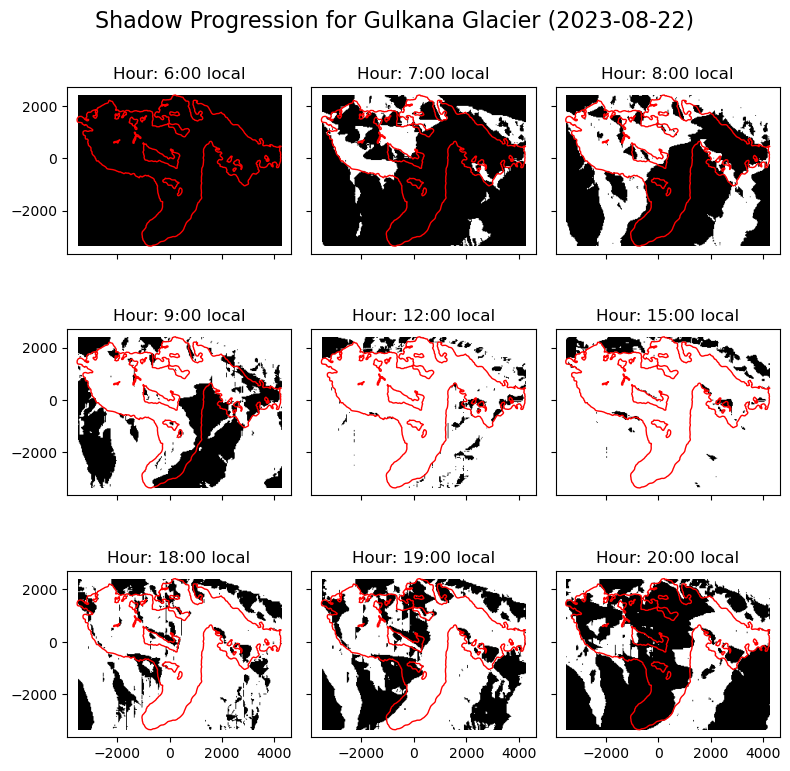

In [ ]:
shading_fp = '/home/claire/Local/data/shading/'

glacier = 'gulkana'
glacier_id = translate_rgi[glacier]['6']
date = '2023-08-22'
target_local_hours = [6, 7, 8, 9, 12, 15, 18, 19, 20]

# load the shading file
file_path = os.path.join(shading_fp, f"{glacier_id}_shadows.zarr")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find shadow file: {file_path}")

ds = xr.open_dataset(file_path)

# apply coordinate corrections as needed
local_times = ds.time.values - np.timedelta64(8, "h")
ds = ds.assign_coords(time=local_times)
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
ds = ds.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])

# select the day specified
date_doy = pd.to_datetime(date).day_of_year
glacier_day = ds.sel(time=ds.time.dt.dayofyear == date_doy)

# initialize plot
fig, axes = plt.subplots(3, 3, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.flatten()

# load the RGI geodataframe for the shapefile
gdf = gpd.read_file('/home/claire/Local/RGI/rgi60/01_rgi60_Alaska/01_rgi60_Alaska.shp')
gdf = gdf.loc[gdf['RGIId'] == 'RGI60-'+glacier_id]
gdf = gdf.to_crs(ds.rio.crs)

# loop through hours
for i, hour in enumerate(target_local_hours):
    ax = axes[i]

    # select the specific hour slice
    hourly_data = glacier_day.sel(time=glacier_day.time.dt.hour == hour)

    # pull out 2D spatial grid
    shadow_grid = hourly_data['shadow_mask'].values.squeeze()

    # Plot the binary shadow map
    # sun = white, shade = black
    im = ax.imshow(
        shadow_grid,
        cmap="gray",
        extent=[
            ds.x.min().item(),
            ds.x.max().item(),
            ds.y.min().item(),
            ds.y.max().item(),
        ],
        origin="upper",
    )

    ax.set_title(f"Hour: {hour}:00 local")

    # plot the shapefile
    gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=1)

fig.suptitle(
    f"Shadow Progression for {glacier.replace('_',' ').capitalize()} Glacier ({date})",
    fontsize=16, y=0.98
)
plt.tight_layout()
plt.savefig('../shadow_map.png', bbox_inches='tight', dpi=300)
plt.show()

ds.close()

### Plot seasonal mass balances

In [ ]:
i = 0

all_mod_albedo = [] 
all_meas_albedo = []

for glacier in site_dict:
    for site in site_dict[glacier]:
        gn = translate_rgi[glacier]['6']
        mb = MassBalance(glacier, site)
        ab = Albedo(glacier, site, 'all')

        # ds = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_06_22_base_0.nc') 
        ds = xr.open_zarr(f'../Output/check_4/{gn}_{i}.zarr')
        ds['time'] = ds.time - pd.Timedelta(hours=8)
        # assert ds.error.sum() < 1e-6

        mb.get_model_mb(ds)
        mb.plot_mb()
        plt.savefig(f'../figs/{glacier}{site}_best_mb.png', dpi=300)
        plt.close()
        
        ab.get_model_albedo(ds)
        # ab.get_deltas()
        for mod, meas in zip(ab.mod, ab.meas):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)
        # plt.savefig(f'../figs/{glacier}{site}_best_albedo.png')
        # plt.show()
        # plt.close()

        i += 1

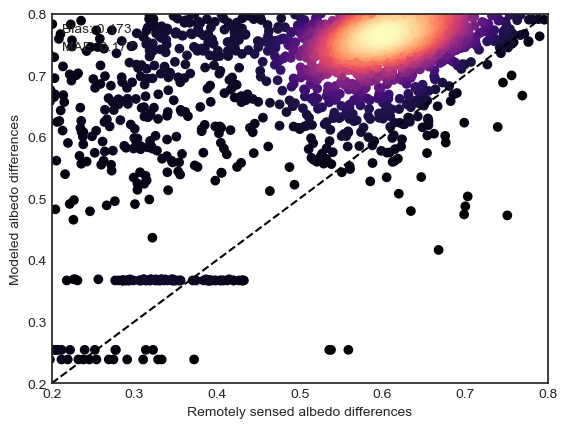

In [ ]:
mod = np.array(all_mod_albedo).flatten()
meas = np.array(all_meas_albedo).flatten()

fig, ax = plt.subplots()
from scipy.stats import gaussian_kde
xy = np.vstack([mod, meas])
kde = gaussian_kde(xy)
z = kde(xy)

idx = z.argsort()
x, y, z = meas[idx], mod[idx], z[idx]

minn, maxx = 0.2,0.8 # -0.8, 0

ax.scatter(x, y, c=z, cmap='magma')
ax.plot([minn, maxx], [minn, maxx], 'k--')
bias = np.mean(mod - meas)
MAE = np.mean(np.abs((mod - meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.90, f'MAE: {MAE:.3f}', transform=ax.transAxes)
ax.set_ylabel('Modeled albedo differences')
ax.set_xlabel('Remotely sensed albedo differences')
ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)
plt.savefig('../figs/new_albedo_agreement.png', dpi=300)
plt.show()

Beginning wolverine N (01.09162). . .
Beginning wolverine B (01.09162). . .
Beginning wolverine EC (01.09162). . .
Beginning kahiltna K53 (01.22193). . .
Beginning kahiltna K17b (01.22193). . .
Beginning kennicott GTL (01.15645). . .
Beginning kennicott GTH (01.15645). . .
Beginning lemon_creek B (01.01104). . .
Beginning lemon_creek C (01.01104). . .
Beginning lemon_creek D (01.01104). . .
Beginning taku NWB1 (01.01390). . .
Beginning taku TKG3 (01.01390). . .
Beginning gulkana AU (01.00570). . .
Beginning gulkana B (01.00570). . .
Beginning gulkana D (01.00570). . .


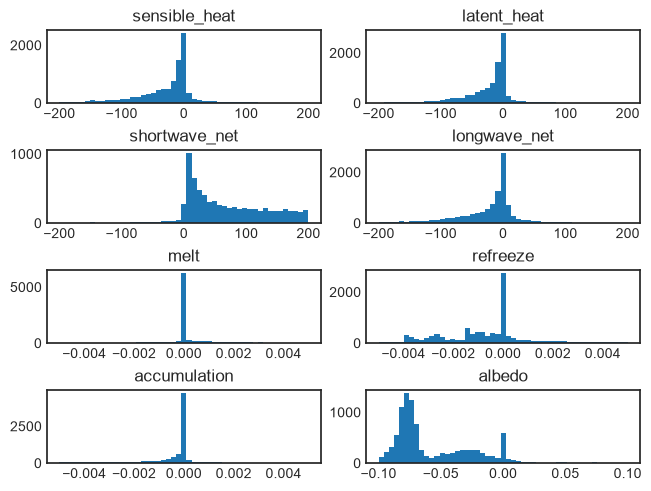

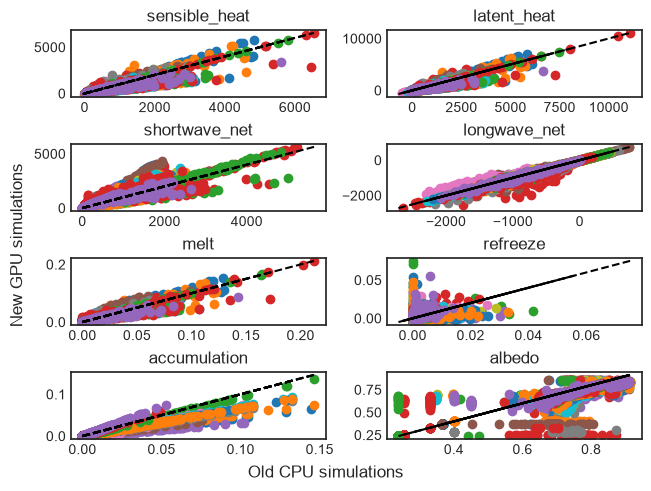

In [42]:
plot_vars = ['sensible_heat', 'latent_heat', 'shortwave_net', 'longwave_net', 'melt','refreeze','accumulation','albedo']
resample = 'D'

fig2, axes2 = plt.subplots(4, 2)
axes2 = axes2.flatten()

all_diff = {}
for var in plot_vars:
    all_diff[var] = []

fig1, axes1 = plt.subplots(4, 2)
axes1 = axes1.flatten()

all_BC = []

i = 0
for glacier in site_dict:
    for site in site_dict[glacier]:
        gn = translate_rgi[glacier]['6']

        print(f'Beginning {glacier} {site} ({gn}). . .')

        
        ds0 = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_07_06_base_0.nc')
        ds1 = xr.open_zarr(f'../Output/check_1/{gn}_{i}.zarr').compute()

        ds0['time'] = ds0.time + pd.Timedelta(hours=10)

        all_BC.append(ds1.layerBC.isel(layer=0).values)

        # common = pd.to_datetime(np.intersect1d(ds0.time.values, ds1.time.values))
        common=pd.date_range('2023-04-20','2025-04-20',freq='h')
        ds0 = ds0.sel(time=common)
        ds1 = ds1.sel(time=common)

        for v, ax1 in zip(plot_vars, axes1):
            if v == 'accumulation':
                v0 = 'accum' 
            elif v == 'shortwave_in':
                v0 = 'SWin'
            elif v == 'longwave_in':
                v0 = 'LWin'
            elif v == 'shortwave_net':
                v0 = 'SWnet'
            elif v == 'longwave_net':
                v0 = 'LWnet'
            elif v.endswith('_heat'):
                v0 = v.split('_')[0]
            else:
                v0 = v

            if resample:
                if v in ['melt','accumulation', 'refreeze'] or 'shortwave' in v or 'longwave' in v or 'heat' in v:
                    vals0 = ds0.isel(layer=0)[v0].resample(time=resample).sum().values
                    vals1 = ds1.isel(layer=0)[v].resample(time=resample).sum().values
                else:
                    vals0 = ds0.isel(layer=0)[v0].resample(time=resample).mean().values
                    vals1 = ds1.isel(layer=0)[v].resample(time=resample).mean().values
            else:
                vals0 = ds0.isel(layer=0)[v0].values 
                vals1 = ds1.isel(layer=0)[v].values

            min_value, max_value = np.min([vals0, vals1]), np.max([vals0, vals1])

            ax1.scatter(vals0, vals1, label=glacier+site)
            ax1.plot([min_value, max_value], [min_value, max_value], 'k--')
        
            diff = vals1 - vals0 
            for d in diff:
                all_diff[v].append(d)
            
            ax1.set_title(v)

        i += 1

mm =[200, 200, 200, 200, 0.005, 0.005, 0.005, 0.1]
for v, ax2, max_abs in zip(plot_vars, axes2, mm):
    # min_val = np.min(all_diff[v])
    # max_val = np.max(all_diff[v])
    # max_abs = max(abs(min_val), abs(max_val)) * 0.1
    ax2.hist(np.array(all_diff[v]), bins=np.linspace(-max_abs, max_abs, 50))
    ax2.set_title(v)

fig1.supxlabel('Old CPU simulations')
fig1.supylabel('New GPU simulations')
fig1.set_constrained_layout(constrained=True)
fig2.set_constrained_layout(constrained=True)
fig1.savefig('../figs/1to1.png')
fig2.savefig('../figs/histogram.png')
plt.show()

<xarray.DataArray 'PHIS' ()> Size: 8B
array(279)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    long_name:       surface geopotential height
    units:           m+2 s-2
    fmissing_value:  1e+15
    standard_name:   surface geopotential height
    vmax:            1e+15
    vmin:            -1e+15
    valid_range:     [-1.e+15  1.e+15]


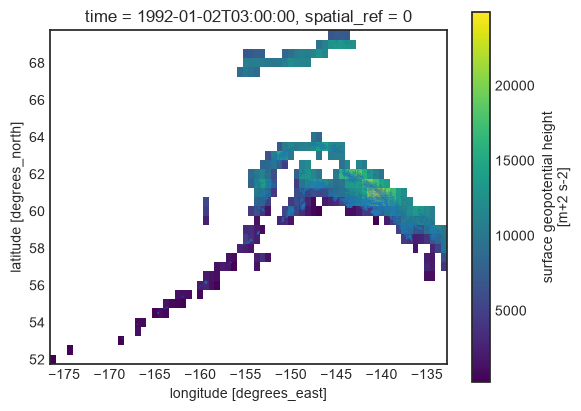

In [40]:
ds = xr.open_dataset('../climate_data/MERRA2/MERRA2_constants.nc')
ds = ds.sel(lat=slice(50, 72), lon=slice(-180, -133))
ds = ds.rio.write_crs("EPSG:4326")
ds = ds.rename({'lat':'y', 'lon':'x'})

import geopandas as gpd
rgi = gpd.read_file('/Users/cvw/local/RGI/rgi60/01_rgi60_Alaska/01_rgi60_Alaska.shp')

if rgi.crs != ds.rio.crs:
    rgi = rgi.to_crs(ds.rio.crs)

clipped_ds = ds.rio.clip(rgi.geometry, rgi.crs, drop=True, all_touched=True)

fig, ax = plt.subplots()
clipped_ds['PHIS'].plot(ax=ax)
rgi.plot(ax=ax)

print(clipped_ds['PHIS'].count())

(array([0.000e+00, 0.000e+00, 1.000e+00, 6.000e+00, 1.100e+01, 3.250e+02,
        3.820e+02, 2.940e+02, 3.700e+02, 4.020e+02, 1.161e+03, 1.000e+03,
        9.520e+02, 9.050e+02, 8.640e+02, 8.100e+02, 1.107e+03, 1.029e+03,
        1.108e+03, 8.360e+02, 1.400e+01, 4.000e+00, 5.000e+00, 5.000e+00,
        2.000e+00, 3.000e+00, 2.000e+00, 3.000e+00, 9.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00]),
 array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
        0.045, 0.05 , 0.055, 0.06 , 0.065, 0.07 , 0.075, 0.08 , 0.085,
        0.09 , 0.095, 0.1  , 0.105, 0.11 , 0.115, 0.12 , 0.125, 0.13 ,
        0.135, 0.14 , 0.145, 0.15 , 0.155, 0.16 , 0.165, 0.17 , 0.175,
        0.18 , 0.185, 0.19 , 0.195]),
 <BarContainer object of 39 artists>)

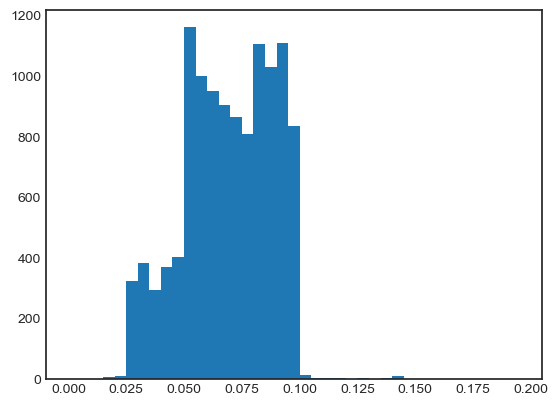

In [174]:
bins = np.arange(0, 0.2, 0.005)
plt.hist(ds1.layerheight.isel(layer=0).values, bins=bins)

In [19]:
glacier, site = 'gulkana','D'
i = 14

gn = translate_rgi[glacier]['6']
ds0 = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_06_30_base_0.nc')
ds1 = xr.open_zarr(f'../Output/check_0/{gn}_{i}.zarr')

assert ds0.attrs['site'] == ds1.attrs['sites']
assert ds0.attrs['elevation'] == ds1.attrs['elevation']

date_local = pd.to_datetime('2024-07-20 14:00')
date_UTC = date_local + pd.Timedelta(hours=10)

print('CPU sim albedo:', ds0.sel(time=date_local).albedo.values)
print('GPU sim albedo:', ds1.sel(time=date_UTC).albedo.values)
print()
print('CPU sim grainsize:', ds0.sel(time=date_local, layer=0).layergrainsize.values)
print('GPU sim grainsize:', ds1.sel(time=date_UTC, layer=0).layergrainsize.values)
print()
print('CPU sim BC:', ds0.sel(time=date_local, layer=0).layerBC.values)
print('GPU sim BC:', ds1.sel(time=date_UTC, layer=0).layerBC.values)
print()

CPU sim albedo: 0.6731770184329119
GPU sim albedo: 0.6486029114499295

CPU sim grainsize: 718.9865556014055
GPU sim grainsize: 851.0573227303465

CPU sim BC: 5.049155541877484
GPU sim BC: 48.82903240471162



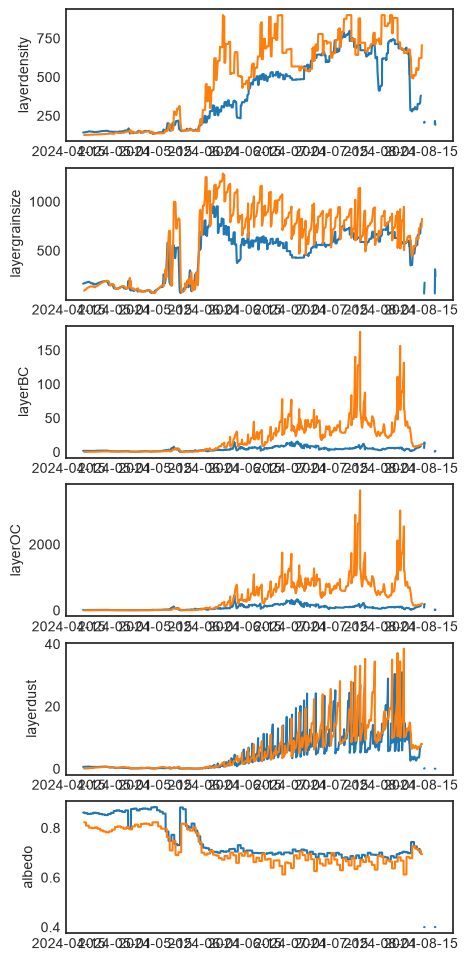

In [21]:
glacier, site = 'gulkana','D'
i = 14

gn = translate_rgi[glacier]['6']
ds0 = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_06_30_base_0.nc')
ds1 = xr.open_zarr(f'../Output/check_0/{gn}_{i}.zarr')

dates = pd.date_range('2024-04-20','2024-08-20', freq='h')

plot_vars = ['layerdensity','layergrainsize', 'layerBC','layerOC','layerdust','albedo']
# plot_vars = ['refreeze']
fig, axes = plt.subplots(len(plot_vars), figsize=(5, 2*len(plot_vars)))

if len(plot_vars) == 1: axes = [axes]

for ax, var in zip(axes, plot_vars):
    ax.set_ylabel(var)
    
    for _ds, label in zip([ds0,ds1], ['Before','After']):
        dates_sel = dates + pd.Timedelta(hours=8) if label =='After' else dates
        ds = _ds.sel(time=dates_sel, layer=0)
        ds = ds.where(ds.layertype == 0)
        ax.plot(ds.time, ds[var])

plt.show()

(<Figure size 500x680 with 8 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

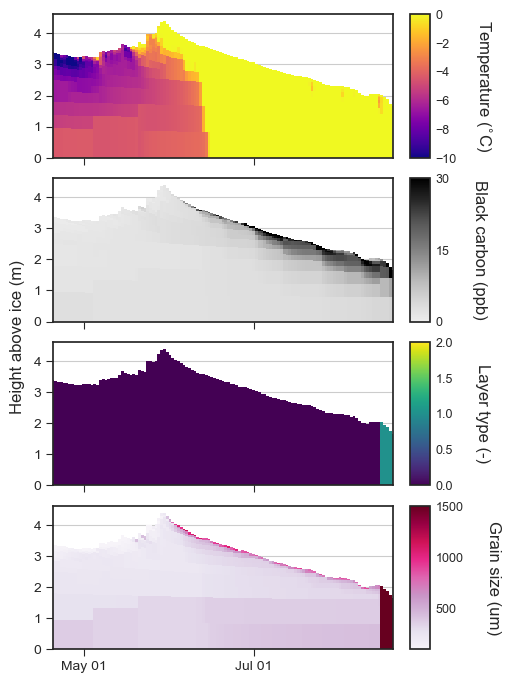

In [95]:

ds = xr.open_zarr(f'../Output/check_5/01.00570_14.zarr')

dates = pd.date_range('2024-04-20','2024-08-20', freq='D')

visualize_layers(ds, dates, ['layertemp','layerBC', 'layertype', 'layergrainsize'])